Oppgave 1 a)

Importerer sympy slik at jeg kan få en nøyaktig derivasjon og importerer numpy og matplotlib.pyplot for å kunne plotte grafer

In [162]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

Definerer variablene som brukes i funksjonen til sympy slik at jeg kan bruke dem i funksjonen
jeg skal derivere

In [163]:
t, K, P0, r = sp.symbols("t K P0 r", real=True)

Her lager jeg funksjonen som skal deriveres

In [164]:
P = K/(1+(K/P0-1)*sp.exp(-r*K*t))
print(P)

K/((K/P0 - 1)*exp(-K*r*t) + 1)


Deriverer funksjonen (P derivert med fokus på t)

In [165]:
dPdx = sp.diff(P, t)
print(dPdx)

K**2*r*(K/P0 - 1)*exp(-K*r*t)/((K/P0 - 1)*exp(-K*r*t) + 1)**2


Her er den deriverte av funksjonen hvor jeg finner P´(0)

In [166]:
dPdx.subs([(t, 0), (K, 5000), (P0, 40), (r, 4)]).evalf()

793600.000000000

Bruker samme metode for substituering av variabler til tall som jeg gjor i derivasjonen og finner P(0)

In [167]:
P1 = P.subs([(t, 0), (K, 5000), (P0, 40), (r, 4)]).evalf()

Legger inn ligningen for startverdi problemet for å sjekke at 𝑃′ = 𝑟𝑃(𝐾 − 𝑃)

In [168]:
4*P1*(5000-P1)

793600.000000000

Oppgave 1 b) Forklar hvorfor P(t) går mot K når t → ∞. Tips: Se på hva som skjer med e^{-rKt} når t blir veldig stor.

Prøver først å plotte grafen slik at jeg bedre kan forstå spørsmålet.

Lager x aksen til grafen ved å legge inn veldig høyt tall som skal forestille t som går mot uendelig.

In [169]:
x = np.linspace(1,1000000, 1000000)

Konverterer funksjonen fra sympy funksjon til python funksjon ved å bruke
 lambdify på P(t) slik at den kan brukes til plotting

In [170]:
P_plot = sp.lambdify((t,K,P0,r), P)

Lager y aksen hvor t blir erstattet med x. K er bærekapasitet, P0 er startverdi, r er vekstraten

In [171]:
y = P_plot(x, K=200, P0=0.02, r=0.000001)

Plotter grafen

[]

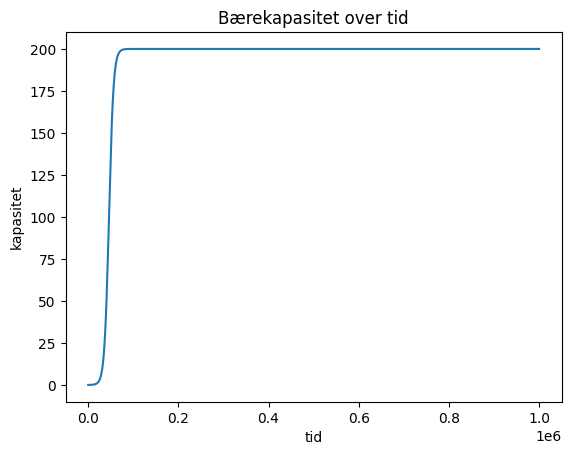

In [172]:
plt.plot(x, y)
plt.title("Bærekapasitet over tid")
plt.xlabel("tid")
plt.ylabel("kapasitet")
plt.plot()